## Review 평점과 Sales 연관성 - EU Data

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

### Data Load

In [6]:
df = pd.read_csv("eu_review_sales.csv")

In [7]:
df

,country_code,yr_month,financial_category,avg_rating,rvw_12_cnt,rvw_all_cnt,ratio_12,sales_amount,sales_qty
0,DE,202503,SmartBases,NaN,NaN,NaN,NaN,4995.26,67.0
1,DE,202503,Toppers,NaN,NaN,NaN,NaN,436.04,10.0
2,DE,202503,Platform Beds,NaN,NaN,NaN,NaN,155905.32,1745.0
3,DE,202503,Non-bedroom furniture,NaN,NaN,NaN,NaN,4773.61,49.0
4,DE,202503,Other,NaN,NaN,NaN,NaN,611.73,7.0
...,...,...,...,...,...,...,...,...,...
1846,UK,202201,SmartBases,5.00,0.0,1.0,0.00,30164.83,513.0
1847,UK,202201,UNKNOWN,5.00,0.0,3.0,0.00,9294.82,63.0
1848,UK,202201,Foam Mattresses,NaN,NaN,NaN,NaN,259.38,2.0
1849,UK,202201,Platform Beds,4.32,2.0,25.0,0.08,254707.16,2822.0


## 국가별 카테고리의 매출 그래프

In [202]:
sales_by_contry_cat = (
    df.groupby(['country_code','financial_category']).agg(sales_amount=('sales_amount','sum'), sales_qty=('sales_qty','sum'))
    .reset_index()
)

In [204]:
sales_filtered = sales_by_contry_cat[~sales_by_contry_cat['financial_category'].isin(['Total','UNKNOWN','Discontinued'])]

In [206]:
sales_filtered

,country_code,financial_category,sales_amount,sales_qty
0,DE,Foam Mattresses,2127562.69,13273.0
1,DE,Non-bedroom furniture,707184.62,9271.0
2,DE,Other,7454.61,129.0
3,DE,Platform Beds,12045494.85,94190.0
4,DE,SmartBases,388740.91,5089.0
5,DE,Sofa,410786.61,2945.0
6,DE,Spring Mattresses,1111817.15,7483.0
7,DE,Toppers,146017.60,3257.0
10,ES,Foam Mattresses,998579.16,8934.0
11,ES,Non-bedroom furniture,1434157.11,19367.0


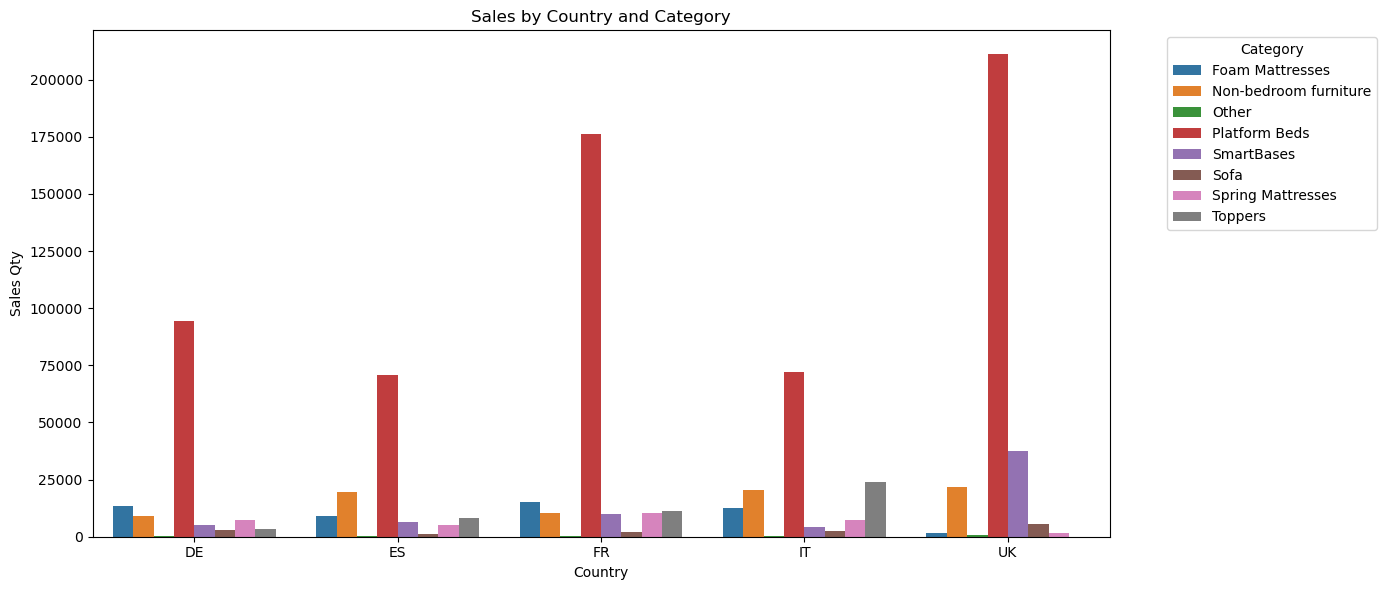

In [208]:
# 시각화
plt.figure(figsize=(14,6))
sns.barplot(
    data=sales_filtered,
    x='country_code',
    y='sales_qty',
    hue='financial_category'
)
plt.title("Sales by Country and Category")
plt.xlabel('Country')
plt.ylabel('Sales Qty')
plt.legend(title='Category', bbox_to_anchor=(1.05,1), loc='upper left')
plt.tight_layout()
plt.show()


## 판매량 대비 리뷰수 비율이 높은 조합

In [114]:
df_filtered = df[df['sales_qty'].notna() & df['rvw_12_cnt'].notna() & ~df['financial_category'].isin(['UNKNOWN', 'Other', 'Total'])]

In [116]:
df_filtered

,country_code,yr_month,financial_category,avg_rating,rvw_12_cnt,rvw_all_cnt,ratio_12,sales_amount,sales_qty
41,DE,202411,Platform Beds,4.000000,0.0,4.0,0.000000,245410.87,2778.0
49,DE,202410,Spring Mattresses,3.500000,1.0,2.0,0.500000,4256.49,38.0
50,DE,202410,SmartBases,5.000000,0.0,1.0,0.000000,2627.30,41.0
54,DE,202410,Platform Beds,4.209302,8.0,43.0,0.186047,195776.98,1822.0
55,DE,202410,Toppers,4.000000,0.0,1.0,0.000000,897.44,30.0
...,...,...,...,...,...,...,...,...,...
1839,UK,202202,SmartBases,1.333333,3.0,3.0,1.000000,20598.31,316.0
1844,UK,202201,Non-bedroom furniture,4.142857,1.0,7.0,0.142857,16416.84,237.0
1846,UK,202201,SmartBases,5.000000,0.0,1.0,0.000000,30164.83,513.0
1849,UK,202201,Platform Beds,4.320000,2.0,25.0,0.080000,254707.16,2822.0


In [148]:
sales_vs_reviews = (
    df_filtered.groupby(['country_code','financial_category'])
    .agg(total_avg_rating=('avg_rating', 'mean'), total_reviews=('rvw_all_cnt', 'sum'), total_12_reviews=('rvw_12_cnt','sum'), total_sales_qty=('sales_qty','sum'))
    .reset_index()    
)

In [150]:
sales_vs_reviews['12_review_per_sales'] = sales_vs_reviews['total_12_reviews'] / sales_vs_reviews['total_sales_qty']

In [152]:
sales_vs_reviews = sales_vs_reviews.sort_values(by='12_review_per_sales', ascending=False)

In [154]:
sales_vs_reviews

,country_code,financial_category,total_avg_rating,total_reviews,total_12_reviews,total_sales_qty,12_review_per_sales
14,FR,Non-bedroom furniture,3.787432,848.0,214.0,9416.0,0.022727
17,FR,Sofa,3.954174,141.0,18.0,1543.0,0.011666
27,UK,Foam Mattresses,3.208333,8.0,4.0,374.0,0.010695
7,ES,Foam Mattresses,3.899506,368.0,80.0,8559.0,0.009347
6,DE,Toppers,3.388021,85.0,27.0,3070.0,0.008795
20,IT,Foam Mattresses,3.939994,463.0,93.0,11471.0,0.008107
4,DE,Sofa,3.900000,13.0,3.0,389.0,0.007712
12,ES,Toppers,3.955717,253.0,50.0,7844.0,0.006374
25,IT,Spring Mattresses,3.948669,275.0,45.0,7118.0,0.006322
13,FR,Foam Mattresses,4.049607,441.0,83.0,14232.0,0.005832


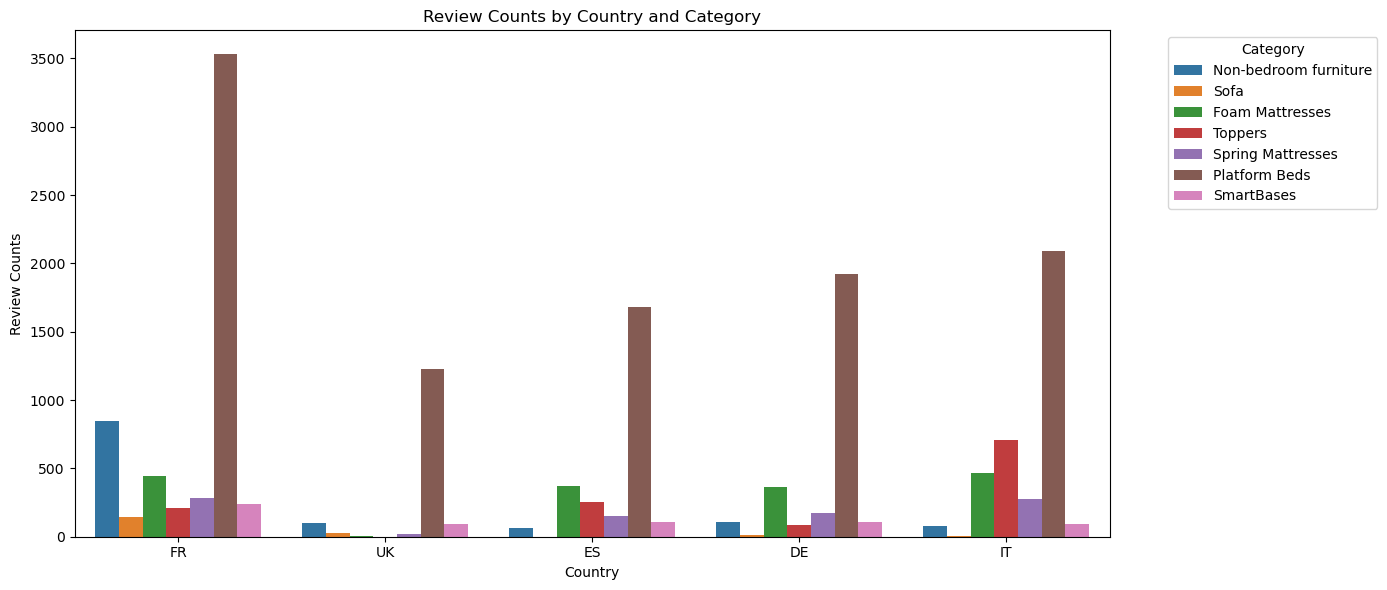

In [212]:
# 국가별, 카테고리별, Review 개수 그래프
plt.figure(figsize=(14,6))
sns.barplot(
    data=sales_vs_reviews,
    x='country_code',
    y='total_reviews',
    hue='financial_category'
)
plt.title("Review Counts by Country and Category")
plt.xlabel('Country')
plt.ylabel('Review Counts')
plt.legend(title='Category', bbox_to_anchor=(1.05,1), loc='upper left')
plt.tight_layout()
plt.show()

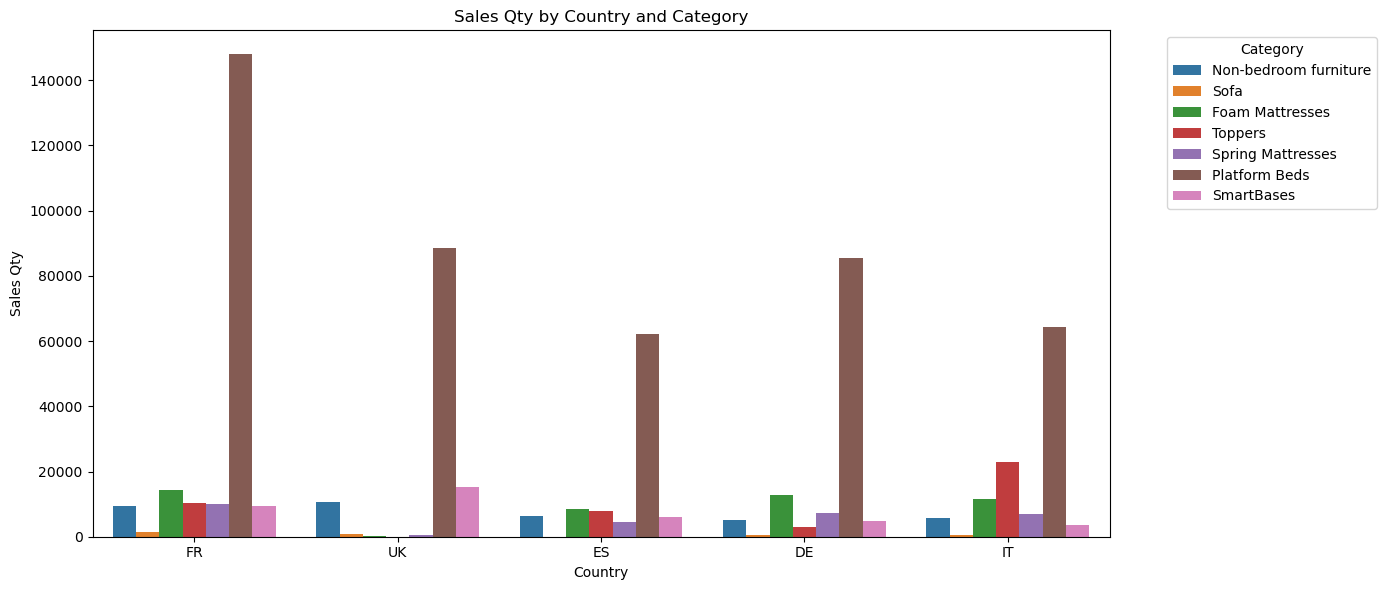

In [216]:
# 국가별, 카테고리별, Sales Qty 그래프
plt.figure(figsize=(14,6))
sns.barplot(
    data=sales_vs_reviews,
    x='country_code',
    y='total_sales_qty',
    hue='financial_category'
)
plt.title("Sales Qty by Country and Category")
plt.xlabel('Country')
plt.ylabel('Sales Qty')
plt.legend(title='Category', bbox_to_anchor=(1.05,1), loc='upper left')
plt.tight_layout()
plt.show()

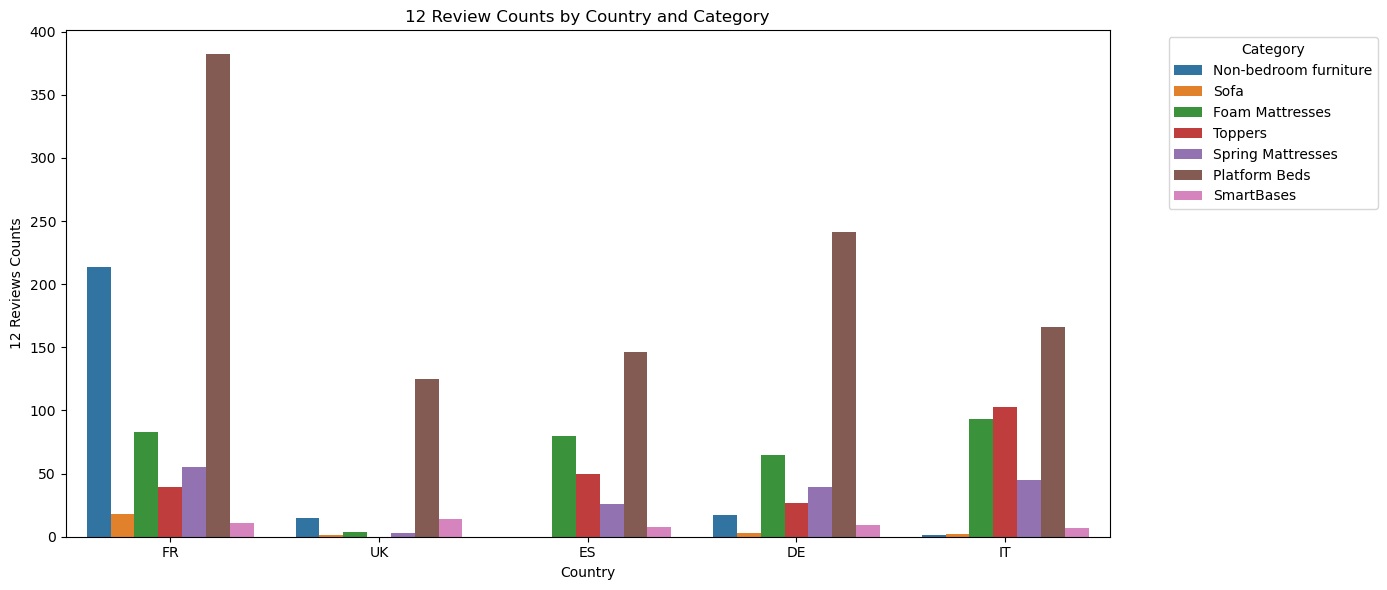

In [220]:
# 국가별, 카테고리별, 12 review counts 그래프
plt.figure(figsize=(14,6))
sns.barplot(
    data=sales_vs_reviews,
    x='country_code',
    y='total_12_reviews',
    hue='financial_category'
)
plt.title("12 Review Counts by Country and Category")
plt.xlabel('Country')
plt.ylabel('12 Reviews Counts')
plt.legend(title='Category', bbox_to_anchor=(1.05,1), loc='upper left')
plt.tight_layout()
plt.show()

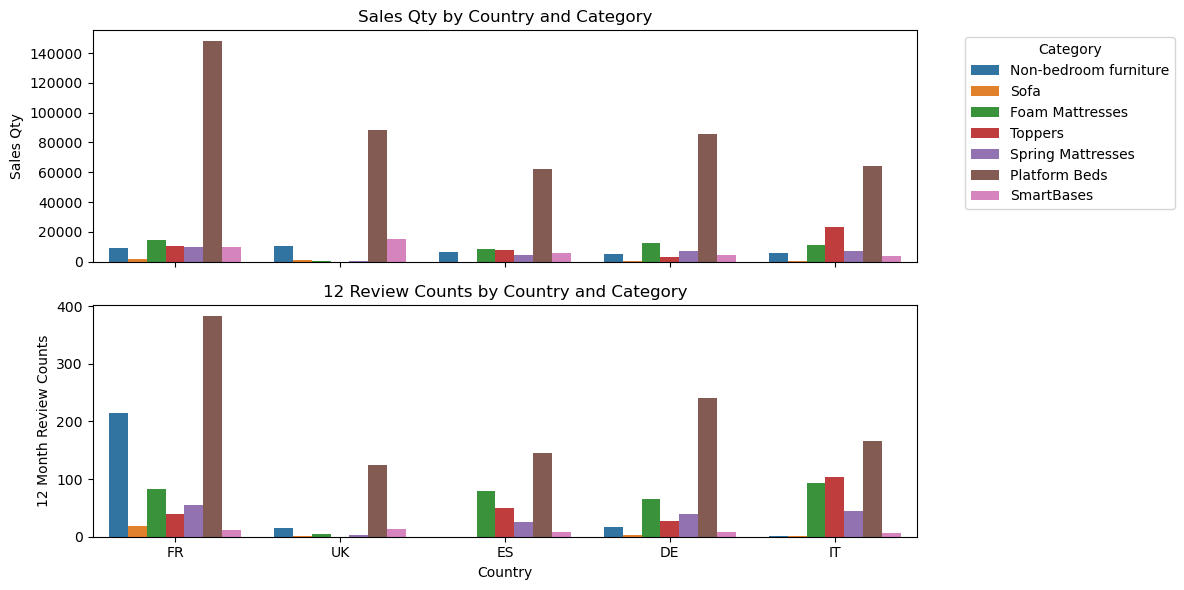

In [232]:
# 서브 플롯 활용
fig, (ax1, ax2) = plt.subplots(2,1,figsize=(12,6), sharex=True)

# 상단 : 판매 수량
sns.barplot(
    data=sales_vs_reviews,
    x='country_code',
    y='total_sales_qty',
    hue='financial_category',
    ax=ax1
)
ax1.set_title("Sales Qty by Country and Category")
ax1.set_ylabel('Sales Qty')
ax1.legend(title='Category',  bbox_to_anchor=(1.05, 1), loc='upper left')

# 하단 : 12 리뷰 개수
sns.barplot(
    data=sales_vs_reviews,
    x='country_code',
    y='total_12_reviews',
    hue='financial_category',
    ax=ax2
)
ax2.set_title("12 Review Counts by Country and Category")
ax2.set_xlabel('Country')
ax2.set_ylabel('12 Month Review Counts')
#ax2.legend(title='Category', bbox_to_anchor=(1.05, 1), loc='upper left')
ax2.legend_.remove()

# 전체 레이아웃 조정
plt.tight_layout()
plt.show()

In [158]:
sales_vs_reviews1 = (sales_vs_reviews.groupby(['financial_category'])
    .agg(total_avg_rating=('total_avg_rating', 'mean'), total_reviews=('total_reviews','sum'), total_12_reviews=('total_12_reviews','sum'), total_sales_qty=('total_sales_qty','sum'))
    .reset_index()
)

In [160]:
sales_vs_reviews1['12_review_per_sales'] = sales_vs_reviews1['total_12_reviews'] / sales_vs_reviews['total_sales_qty']

In [162]:
sales_vs_reviews1.sort_values(by='12_review_per_sales', ascending=False)

,financial_category,total_avg_rating,total_reviews,total_12_reviews,total_sales_qty,12_review_per_sales
6,Toppers,3.812558,1253.0,219.0,44195.0,0.071336
4,Sofa,3.755012,188.0,24.0,3379.0,0.061697
1,Non-bedroom furniture,4.386250,1195.0,247.0,37377.0,0.047427
0,Foam Mattresses,3.824440,1646.0,325.0,47365.0,0.025532
5,Spring Mattresses,3.920865,911.0,168.0,29542.0,0.022976
2,Platform Beds,4.386741,10451.0,1060.0,448541.0,0.012393
3,SmartBases,4.466934,636.0,49.0,38973.0,0.010381


## 카테고리별 평점 & 매출 추이 

## 평점 수준별 매출 히스토그램

In [49]:
bins = [i/10 for i in range(int(data1['avg_rating'].min()*10), int(data1['avg_rating'].max() * 10) + 2)]

In [51]:
data1['rating_bin'] = pd.cut(data1['avg_rating'], bins=bins, right=False)

In [53]:
data1

,yr_month,global_category,avg_rating,rvw_12_cnt,rvw_all_cnt,ratio_12,sales_amount,sales_qty,rating_bin
0,202201,UNKNOWN,4.212840,253.0,1729.0,0.146327,9294.82,63,"[4.2, 4.3)"
1,202201,Total,4.214609,256.0,1766.0,0.144960,328050.16,3838,"[4.2, 4.3)"
2,202201,Spring Mattresses,4.250000,0.0,4.0,0.000000,17047.09,189,"[4.2, 4.3)"
4,202201,SmartBases,5.000000,0.0,1.0,0.000000,30164.83,513,"[5.0, 5.1)"
5,202201,Platform Beds,4.320000,2.0,25.0,0.080000,254707.16,2822,"[4.3, 4.4)"
...,...,...,...,...,...,...,...,...,...
276,202408,Total,4.298137,23.0,161.0,0.142857,722575.71,11112,"[4.2, 4.3)"
283,202409,UNKNOWN,4.181818,30.0,165.0,0.181818,116069.45,1325,"[4.1, 4.2)"
284,202409,Total,4.181818,30.0,165.0,0.181818,649100.21,8855,"[4.1, 4.2)"
291,202410,UNKNOWN,4.406780,19.0,177.0,0.107345,191412.75,3300,"[4.4, 4.5)"


In [90]:
rating_sales = data.groupby(["rating_bin", "category_type"])["sales_amount"].sum().unstack().fillna(0) / 1000000

C:\Users\최태욱\AppData\Local\Temp\ipykernel_14772\1249324559.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  rating_sales = data.groupby(["rating_bin", "category_type"])["sales_amount"].sum().unstack().fillna(0) / 1000000


In [112]:
rating_sales_by_category = data.groupby(['rating_bin','financial_category'])['sales_amount'].sum().unstack().fillna(0)/1000000

C:\Users\최태욱\AppData\Local\Temp\ipykernel_14772\3906643850.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  rating_sales_by_category = data.groupby(['rating_bin','financial_category'])['sales_amount'].sum().unstack().fillna(0)/1000000


In [114]:
rating_sales_by_category

financial_category,Box Springs,Foam Mattresses,Non Bedroom Furniture,Other Frames & Beds,Others,Platform Beds,SmartBases,Sofa,Spring Mattresses,Toppers
rating_bin,,,,,,,,,,
"[1.0, 1.1)",0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.089498,0.000000,0.000000
"[1.1, 1.2)",0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
"[1.2, 1.3)",0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
"[1.3, 1.4)",0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
"[1.4, 1.5)",0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
"[1.5, 1.6)",0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
"[1.6, 1.7)",0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
"[1.7, 1.8)",0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
"[1.8, 1.9)",0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


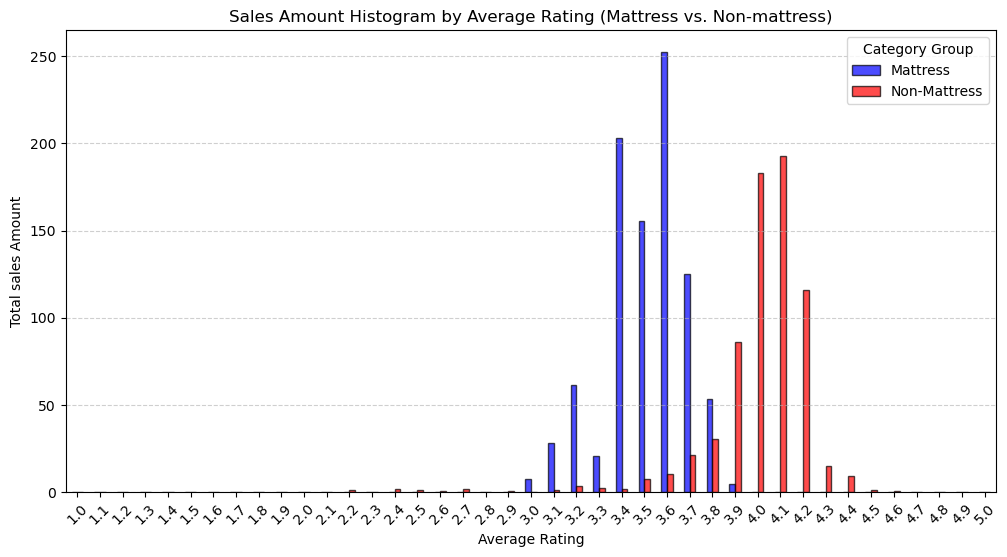

In [92]:
fig, ax = plt.subplots(figsize=(12,6))
rating_sales.plot(kind='bar', stacked=False, color=['blue','red'], edgecolor='black', alpha=0.7, ax=ax)

x_labels = [round(b.left, 1) for b in rating_sales.index]
ax.set_xticklabels(x_labels, rotation=45)

plt.xlabel("Average Rating")
plt.ylabel("Total sales Amount")
plt.title("Sales Amount Histogram by Average Rating (Mattress vs. Non-mattress)")
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.legend(title="Category Group", labels=["Mattress", "Non-Mattress"])

plt.show()





## Category별 히스토그램 

In [77]:
data

,yr_month,financial_category,written_avg_rating,written_12_cnt,written_all_cnt,written_12_ratio,all_avg_rating,all_12_cnt,all_all_cnt,all_12_ratio,sales_amount,sales_qty,category_type,rating_bin
0,2022-12-01,SmartBases,4.038674,37,181,0.204420,4.512716,73.0,983.0,0.074262,1729285.82,17377,Non-Mattress,"[4.0, 4.1)"
1,2024-12-01,Platform Beds,3.854545,103,440,0.234091,3.854545,103.0,440.0,0.234091,4021850.94,40099,Non-Mattress,"[3.8, 3.9)"
2,2023-09-01,Toppers,3.106061,31,66,0.469697,4.163462,61.0,416.0,0.146635,240646.93,4615,Non-Mattress,"[3.1, 3.2)"
3,2022-01-01,Non Bedroom Furniture,3.853333,19,75,0.253333,NaN,NaN,NaN,NaN,518281.03,4766,Non-Mattress,"[3.8, 3.9)"
4,2024-11-01,Others,5.000000,0,2,0.000000,4.833333,0.0,6.0,0.000000,41752.46,1279,Non-Mattress,"[5.0, 5.1)"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
385,2023-03-01,Toppers,2.700637,89,157,0.566879,3.853425,166.0,730.0,0.227397,1018152.28,20058,Non-Mattress,"[2.7, 2.8)"
386,2023-11-01,Box Springs,3.840206,49,194,0.252577,4.371156,100.0,943.0,0.106045,4148741.49,31839,Non-Mattress,"[3.8, 3.9)"
387,2022-02-01,Box Springs,4.133739,56,329,0.170213,NaN,NaN,NaN,NaN,6632445.72,48676,Non-Mattress,"[4.1, 4.2)"
388,2024-01-01,Toppers,3.041667,21,48,0.437500,4.150602,48.0,332.0,0.144578,185152.78,3537,Non-Mattress,"[3.0, 3.1)"


In [96]:
categories = data['financial_category'].unique()
num_categories = len(categories)

In [98]:
bins1 = [round(x * 0.1, 1) for x in range(int(data['written_avg_rating'].min()*10)-1, int(data['written_avg_rating'].max()*10)+2)]
#subset['rating_bin']=data.cut(subset['written_avg_rating'], bins=bins1)

C:\Users\최태욱\AppData\Local\Temp\ipykernel_14772\2937017614.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  rating_sales_sum = subset.groupby('rating_bin1')['sales_amount'].sum().fillna(0) / 1000000
C:\Users\최태욱\AppData\Local\Temp\ipykernel_14772\2937017614.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  rating_sales_sum = subset.groupby('rating_bin1')['sales_amount'].sum().fillna(0) / 1000000
C:\Users\최태욱\AppData\Local\Temp\ipykernel_14772\2937017614.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain

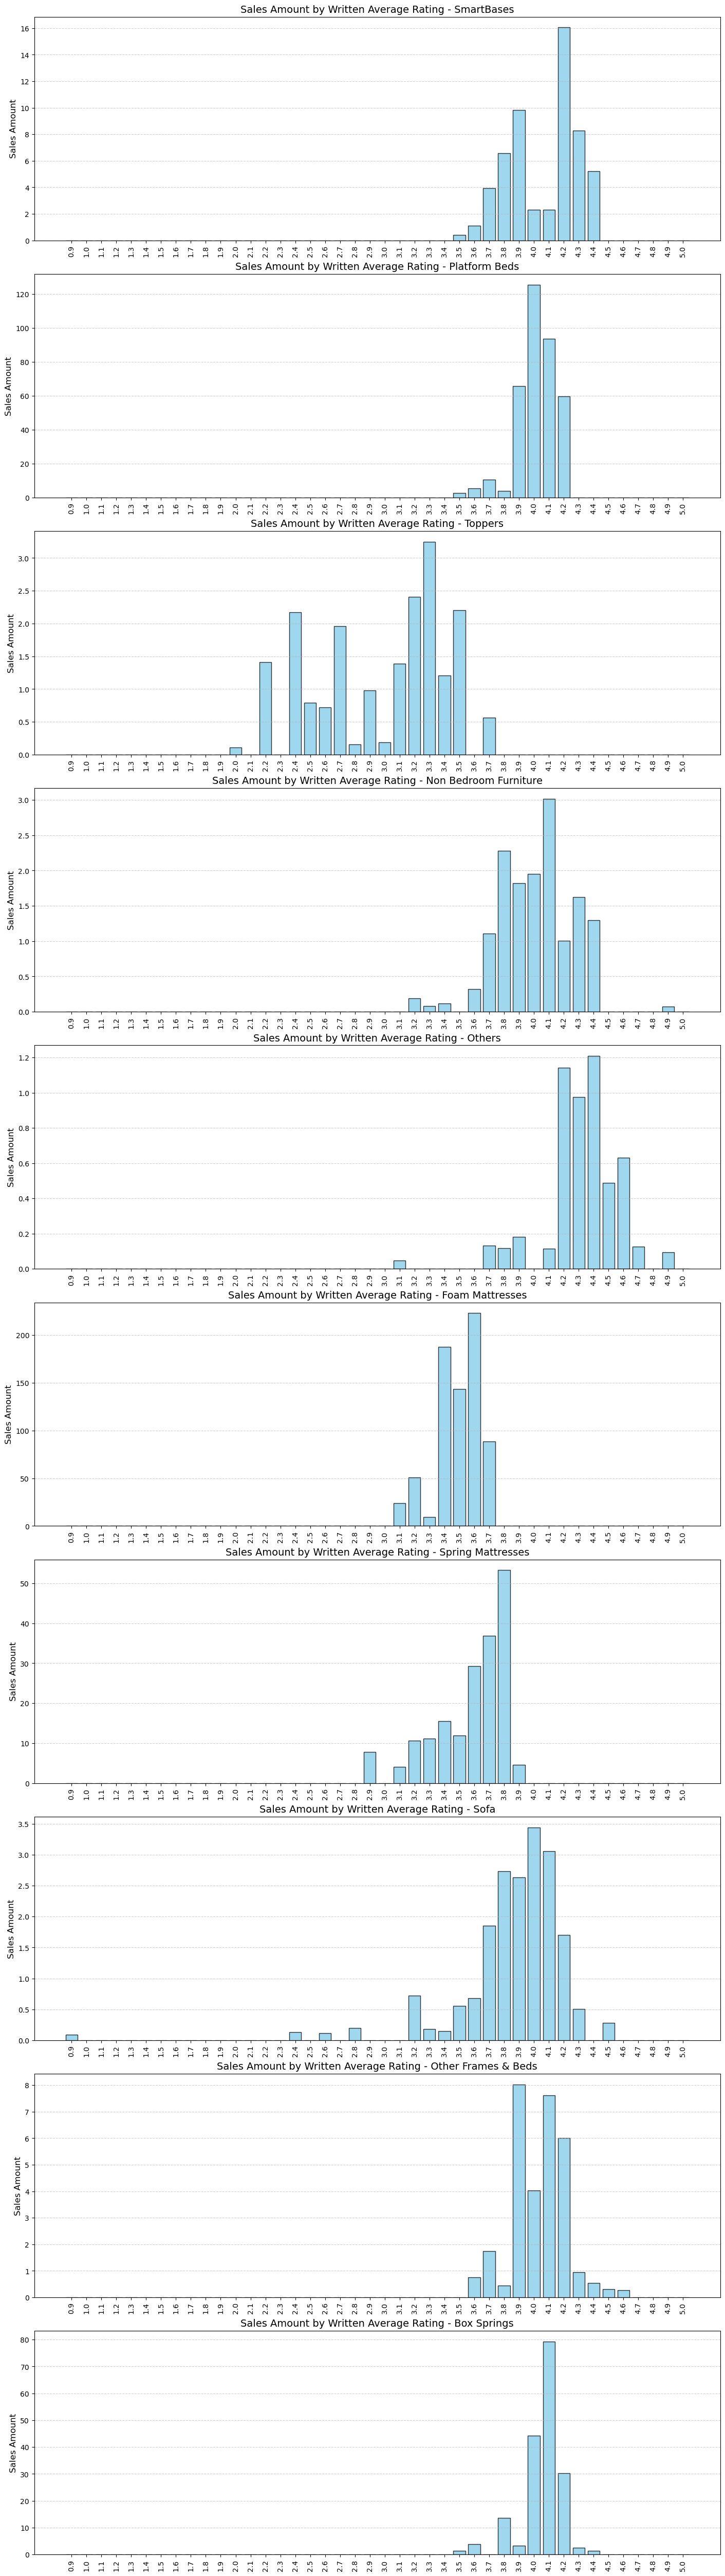

In [116]:
fig, axes = plt.subplots(num_categories, 1, figsize=(14,5*num_categories), constrained_layout=True)

for i, category in enumerate(categories):
    subset = data[data['financial_category']==category].copy()
    subset['rating_bin1'] = pd.cut(subset['written_avg_rating'], bins=bins1)
    rating_sales_sum = subset.groupby('rating_bin1')['sales_amount'].sum().fillna(0) / 1000000

    x_labels = [round(interval.left,1) for interval in rating_sales_sum.index]
    
    axes[i].bar(range(len(x_labels)), rating_sales_sum.values, color='skyblue', edgecolor='black', alpha=0.8)
    axes[i].set_title(f'Sales Amount by Written Average Rating - {category}', fontsize=14)
    #axes[i].set_xlabel('Written Average Rating (0.1 intervals)', fontsize=12)
    axes[i].set_ylabel('Sales Amount', fontsize=12)
    axes[i].set_xticks(range(len(x_labels)))
    axes[i].set_xticklabels(x_labels, rotation=90)
    axes[i].grid(axis='y', linestyle='--', alpha=0.6)

plt.show()